In [175]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import csv
import cv2
from tqdm import tqdm
import time
import logging


In [176]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [177]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [178]:
!pip install -U albumentations

In [179]:
from pathlib import Path
import json
import random
import re
from collections import Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt

try:
    import albumentations as A
except Exception:
    A = None


ROOT = Path.cwd() / "data_daxuli"  # Default root directory for data; can be overridden in notebooks
TRAIN_MANIFEST = ROOT / "train" / "manifest.json"
VAL_MANIFEST = ROOT / "validation" / "manifest.json"
TEST_MANIFEST = ROOT / "test" / "manifest.json"


# VN-safe preset: keep Vietnamese marks, reduce aggressive deformation
VN_SAFE_CONFIG = {
    "aug": {
        "p_apply": 0.5,
        "shear_range": (-0.4, 0.4),
        "rotation_range": (-5.0, 5.0),
        "elastic_sigma": [3, 5],
        "elastic_alpha": [30, 50],
        "geometric_distort_limit": 0.2,
        "geometric_perspective_scale": (0.01, 0.03),
    },
    "tta": {
        "num_shear": 4,
        "num_rot": 4,
        "shear_range": (-0.2, 0.2),
        "rotation_range": (-1.0, 1.0),
        "lambda": 1.0,
        "omega": 0.25,
    },
    "label": {
        "lowercase": True,
        "remove_punctuation": False,
    },
}

print(f"Albumentations available: {A is not None}")


Albumentations available: True


In [180]:
import logging
import time

# Reset lại tất cả các handlers cũ
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Cấu hình lại từ đầu
logging.basicConfig(
    filename='training_debug.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w', # 'w' để ghi đè mới mỗi lần chạy
    force=True    # Ép buộc áp dụng cấu hình này (chỉ có từ Python 3.8+)
)
logger = logging.getLogger(__name__)

In [181]:
def load_manifest(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def flatten_entries(manifest_obj):
    out = []
    for sample in manifest_obj:
        for item in sample.get("images", []):
            out.append(item)
    return out


train_entries = flatten_entries(load_manifest(TRAIN_MANIFEST))
val_entries = flatten_entries(load_manifest(VAL_MANIFEST))
test_entries = flatten_entries(load_manifest(TEST_MANIFEST))

print(f"Train lines: {len(train_entries)}")
print(f"Val lines:   {len(val_entries)}")
print(f"Test lines:  {len(test_entries)}")

# Quick Vietnamese label diagnostics
all_texts = [x["text"] for x in train_entries + val_entries + test_entries]
num_upper = sum(any(ch.isupper() for ch in t) for t in all_texts)
num_punct = sum(bool(re.search(r"[^\w\s]", t, flags=re.UNICODE)) for t in all_texts)

print(f"Lines containing uppercase: {num_upper}/{len(all_texts)}")
print(f"Lines containing punctuation: {num_punct}/{len(all_texts)}")

Train lines: 4993
Val lines:   1181
Test lines:  1055
Lines containing uppercase: 5088/7229
Lines containing punctuation: 6513/7229


In [182]:
import cv2
import numpy as np
from tqdm import tqdm

def check_text_coverage(entries, root_path, threshold=0.1):
    short_samples = []
    all_ratios    = []

    for item in tqdm(entries, desc="Đang kiểm tra"):
        img_path = root_path / item["image"]
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Tìm cột ngoài cùng bên phải có pixel sáng (chữ)
        col_max      = img.max(axis=0)           # max pixel theo từng cột
        nonzero_cols = np.where(col_max > 20)[0] # cột nào có chữ

        if len(nonzero_cols) == 0:
            ratio = 0.0
        else:
            text_width = nonzero_cols[-1] - nonzero_cols[0] + 1
            ratio      = text_width / img.shape[1]

        all_ratios.append(ratio)

        if ratio < threshold:
            short_samples.append({
                "image": item["image"],
                "text" : item.get("text", ""),
                "ratio": ratio
            })

    print(f"\nTổng ảnh: {len(all_ratios)}")
    print(f"Ảnh có chữ < {threshold*100:.0f}% chiều rộng: "
          f"{len(short_samples)} ({len(short_samples)/len(all_ratios)*100:.1f}%)")
    print(f"\nRatio trung bình : {np.mean(all_ratios):.2f}")
    print(f"Ratio thấp nhất  : {np.min(all_ratios):.2f}")
    print(f"Ratio cao nhất   : {np.max(all_ratios):.2f}")

    # Phân phối
    bins = [0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
    print(f"\nPhân phối ratio:")
    for i in range(len(bins)-1):
        count = sum(bins[i] <= r < bins[i+1] for r in all_ratios)
        bar   = "█" * (count // 10)
        print(f"  {bins[i]:.1f} - {bins[i+1]:.1f} : {count:4d} ảnh  {bar}")

    return short_samples, all_ratios


short_samples, all_ratios = check_text_coverage(
    train_entries + val_entries + test_entries,
    ROOT,
    threshold=0.2
)

Đang kiểm tra: 100%|██████████| 7229/7229 [00:01<00:00, 5185.78it/s]


Tổng ảnh: 7229
Ảnh có chữ < 20% chiều rộng: 444 (6.1%)

Ratio trung bình : 0.41
Ratio thấp nhất  : 0.03
Ratio cao nhất   : 0.88

Phân phối ratio:
  0.0 - 0.1 :  143 ảnh  ██████████████
  0.1 - 0.2 :  301 ảnh  ██████████████████████████████
  0.2 - 0.3 :  485 ảnh  ████████████████████████████████████████████████
  0.3 - 0.5 : 5071 ảnh  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  0.5 - 0.7 : 1214 ảnh  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  0.7 - 

In [183]:
very_short_samples = [s for s in short_samples if s['ratio'] < 0.2]

print(f"Số lượng ảnh có ratio < 0.2: {len(very_short_samples)}")

Số lượng ảnh có ratio < 0.2: 444


In [184]:
# Lấy danh sách tên các file ảnh có ratio < 0.2
paths_to_remove = {s['image'] for s in short_samples if s['ratio'] < 0.2}

print(f"Số lượng ảnh chuẩn bị xóa: {len(paths_to_remove)}")

Số lượng ảnh chuẩn bị xóa: 444


In [185]:
# Lọc tập Train
train_entries_clean = [item for item in train_entries if item["image"] not in paths_to_remove]

# Lọc tập Val
val_entries_clean = [item for item in val_entries if item["image"] not in paths_to_remove]

# Lọc tập Test
test_entries_clean = [item for item in test_entries if item["image"] not in paths_to_remove]

# Kiểm tra kết quả
print(f"Train: {len(train_entries)} -> {len(train_entries_clean)} (Đã xóa {len(train_entries) - len(train_entries_clean)})")
print(f"Val:   {len(val_entries)} -> {len(val_entries_clean)} (Đã xóa {len(val_entries) - len(val_entries_clean)})")
print(f"Test:  {len(test_entries)} -> {len(test_entries_clean)} (Đã xóa {len(test_entries) - len(test_entries_clean)})")

# Cập nhật lại các biến gốc nếu bạn muốn
train_entries = train_entries_clean
val_entries = val_entries_clean
test_entries = test_entries_clean

Train: 4993 -> 4686 (Đã xóa 307)
Val:   1181 -> 1108 (Đã xóa 73)
Test:  1055 -> 991 (Đã xóa 64)


In [186]:
def ensure_binary_black_bg(img: np.ndarray) -> np.ndarray:
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Làm mờ nhẹ để nối các nét chữ bị đứt do biến dạng/resize
    img_blurred = cv2.GaussianBlur(img, (1, 1), 0)
    
    # 2. Sử dụng Otsu để nhị phân hóa tự động
    _, out = cv2.threshold(img_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. KIỂM TRA POLARITY: Đảm bảo nền luôn đen (0), chữ luôn trắng (255)
    h, w = out.shape
    corners = [out[0, 0], out[0, -1], out[-1, 0], out[-1, -1]]
    if np.mean(corners) > 127:
        out = 255 - out
        
    return out


def shear_image(img: np.ndarray, k: float):
    h, w = img.shape[:2]
    # x' = x + k*y
    M = np.array([[1.0, k, 0.0], [0.0, 1.0, 0.0]], dtype=np.float32)
    new_w = int(w + abs(k) * h)
    if k < 0:
        M[0, 2] = abs(k) * h
    sheared = cv2.warpAffine(
        img,
        M,
        (new_w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    # Back to original width for stable training shape
    sheared = cv2.resize(sheared, (w, h), interpolation=cv2.INTER_LINEAR)
    return ensure_binary_black_bg(sheared)


def rotate_image(img: np.ndarray, angle_deg: float):
    if A is None: return ensure_binary_black_bg(img)
    h, w = img.shape[:2]
    
    # SafeRotate tự động tính toán để không mất chữ ở góc
    aug = A.Compose([
        A.SafeRotate(limit=(angle_deg, angle_deg), p=1.0, border_mode=0)
    ])
    
    rotated = aug(image=img)["image"]
    # Ép về kích thước chuẩn 64x2048
    rotated = cv2.resize(rotated, (w, h), interpolation=cv2.INTER_LINEAR)
    return ensure_binary_black_bg(rotated)


def elastic_image(img: np.ndarray, sigma: int, alpha: int):
    if A is None:
        return ensure_binary_black_bg(img)
    aug = A.ElasticTransform(alpha=float(alpha), sigma=float(sigma), p=1.0)
    out = aug(image=img)["image"]
    return ensure_binary_black_bg(out)


def geometric_image(img: np.ndarray):
    if A is None:
        return ensure_binary_black_bg(img)
    
    h, w = img.shape[:2]
    
    # Bước 1: Thêm Padding đen ở biên trái/phải/trên/dưới (ví dụ 30px) 
    # để bảo vệ các ký tự sát lề khỏi bị cắt khi biến dạng
    aug_pipeline = A.Compose([
        A.PadIfNeeded(min_height=h, min_width=w + 200, border_mode=0, position='center'),
        A.OneOf([
            A.OpticalDistortion(distort_limit=VN_SAFE_CONFIG["aug"]["geometric_distort_limit"], p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=VN_SAFE_CONFIG["aug"]["geometric_distort_limit"], p=1.0),
            A.Perspective(scale=VN_SAFE_CONFIG["aug"]["geometric_perspective_scale"], p=1.0),
        ], p=1.0),
    ])
    
    out = aug_pipeline(image=img)["image"]
    
    # Bước 2: Resize về lại (w, h)
    out = cv2.resize(out, (w, h), interpolation=cv2.INTER_LINEAR)
    return ensure_binary_black_bg(out)


def apply_single_aug_paper(img: np.ndarray, p_apply: float = None):
    if p_apply is None:
        p_apply = VN_SAFE_CONFIG["aug"]["p_apply"]

    if random.random() > p_apply:
        return ensure_binary_black_bg(img), "none"

    op = random.choice(["shear", "rotation", "elastic", "geometric"])

    if op == "shear":
        lo, hi = VN_SAFE_CONFIG["aug"]["shear_range"]
        k = random.uniform(lo, hi)
        return shear_image(img, k), f"shear(k={k:.3f})"

    if op == "rotation":
        lo, hi = VN_SAFE_CONFIG["aug"]["rotation_range"]
        theta = random.uniform(lo, hi)
        return rotate_image(img, theta), f"rotation(theta={theta:.2f})"

    if op == "elastic":
        sigma = random.choice(VN_SAFE_CONFIG["aug"]["elastic_sigma"])
        alpha = random.choice(VN_SAFE_CONFIG["aug"]["elastic_alpha"])
        return elastic_image(img, sigma, alpha), f"elastic(sigma={sigma}, alpha={alpha})"

    return geometric_image(img), "geometric(distort/stretch/perspective)"

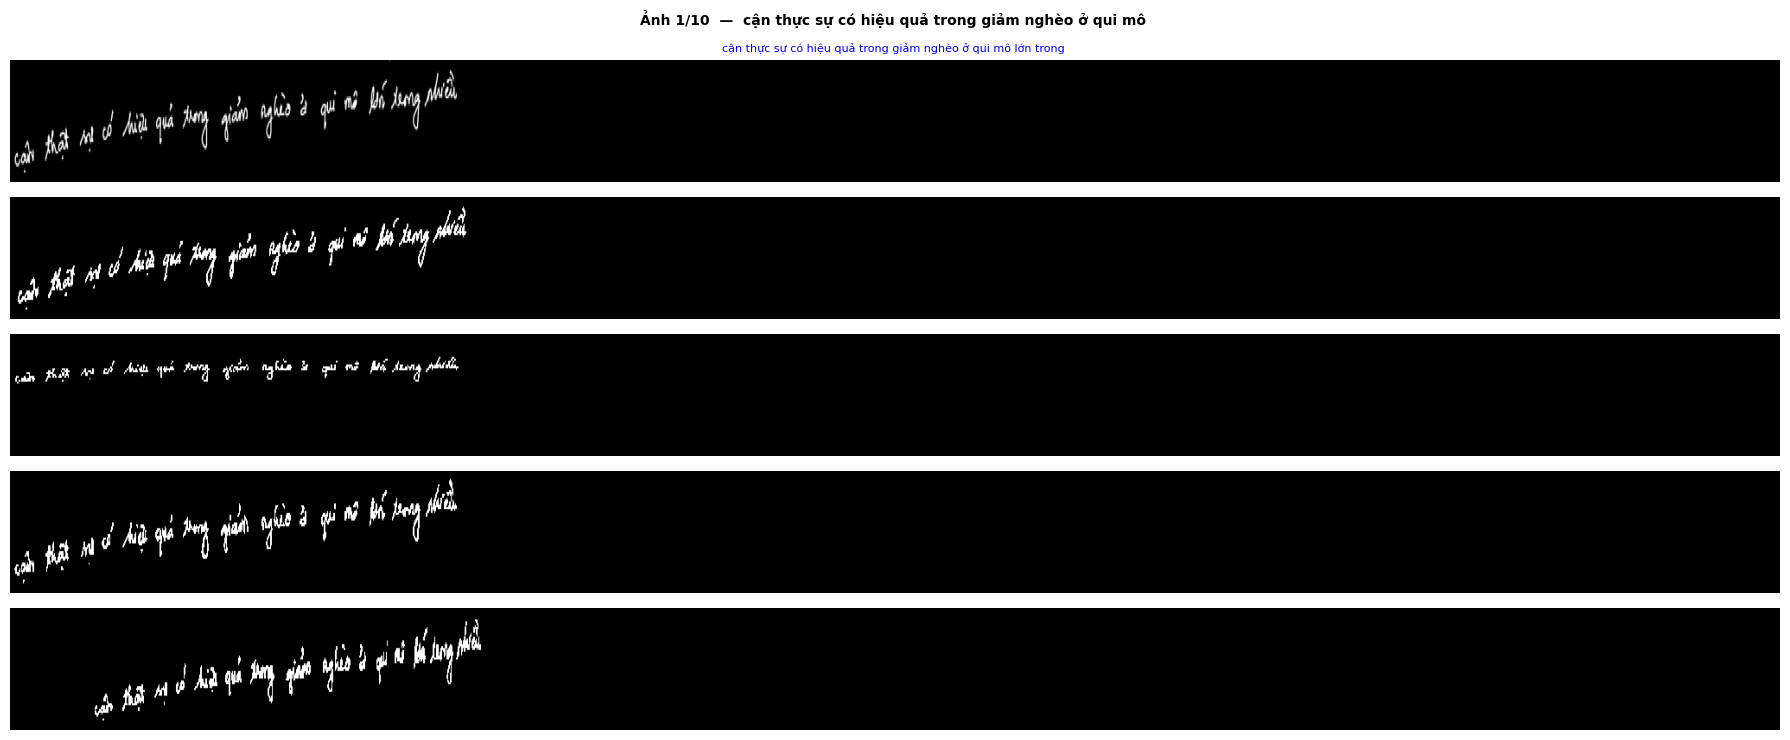

[1] cận thực sự có hiệu quả trong giảm nghèo ở qui mô lớn trong nhiều


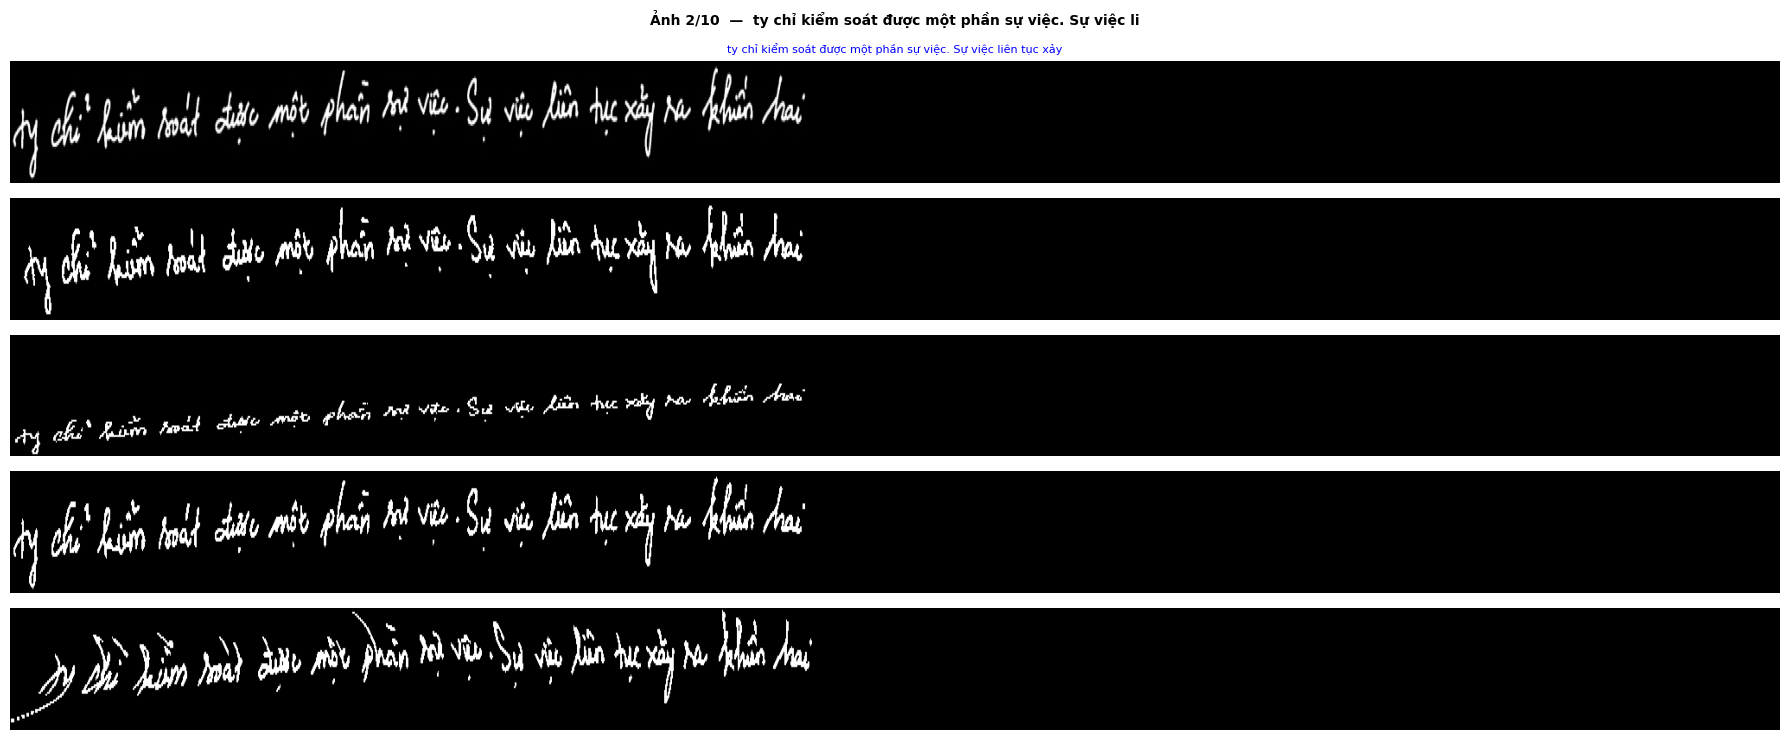

[2] ty chỉ kiểm soát được một phần sự việc. Sự việc liên tục xảy ra khiến hai


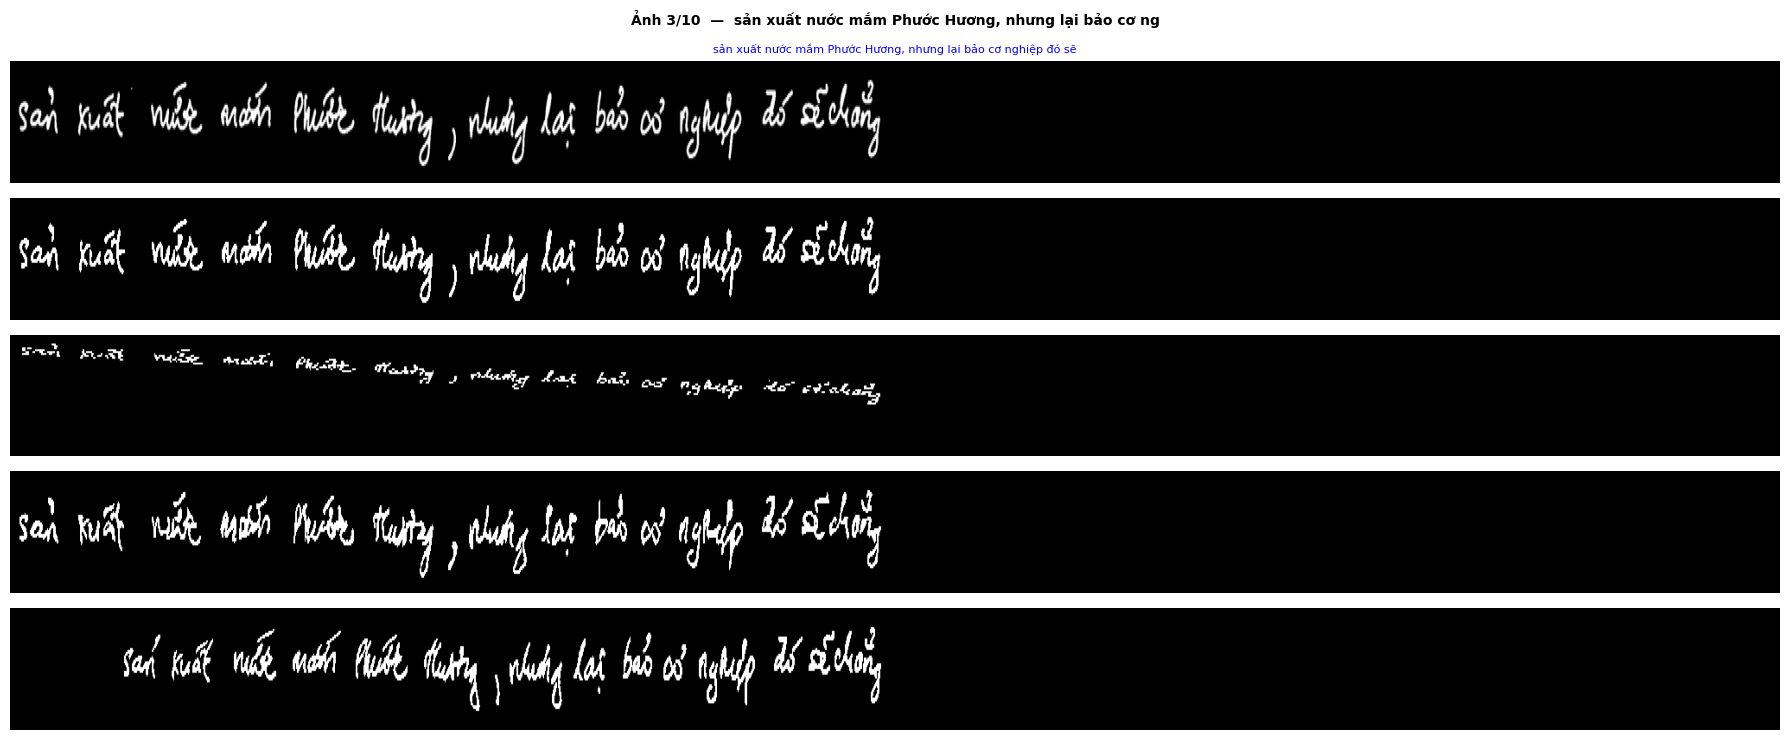

[3] sản xuất nước mắm Phước Hương, nhưng lại bảo cơ nghiệp đó sẽ chẳng


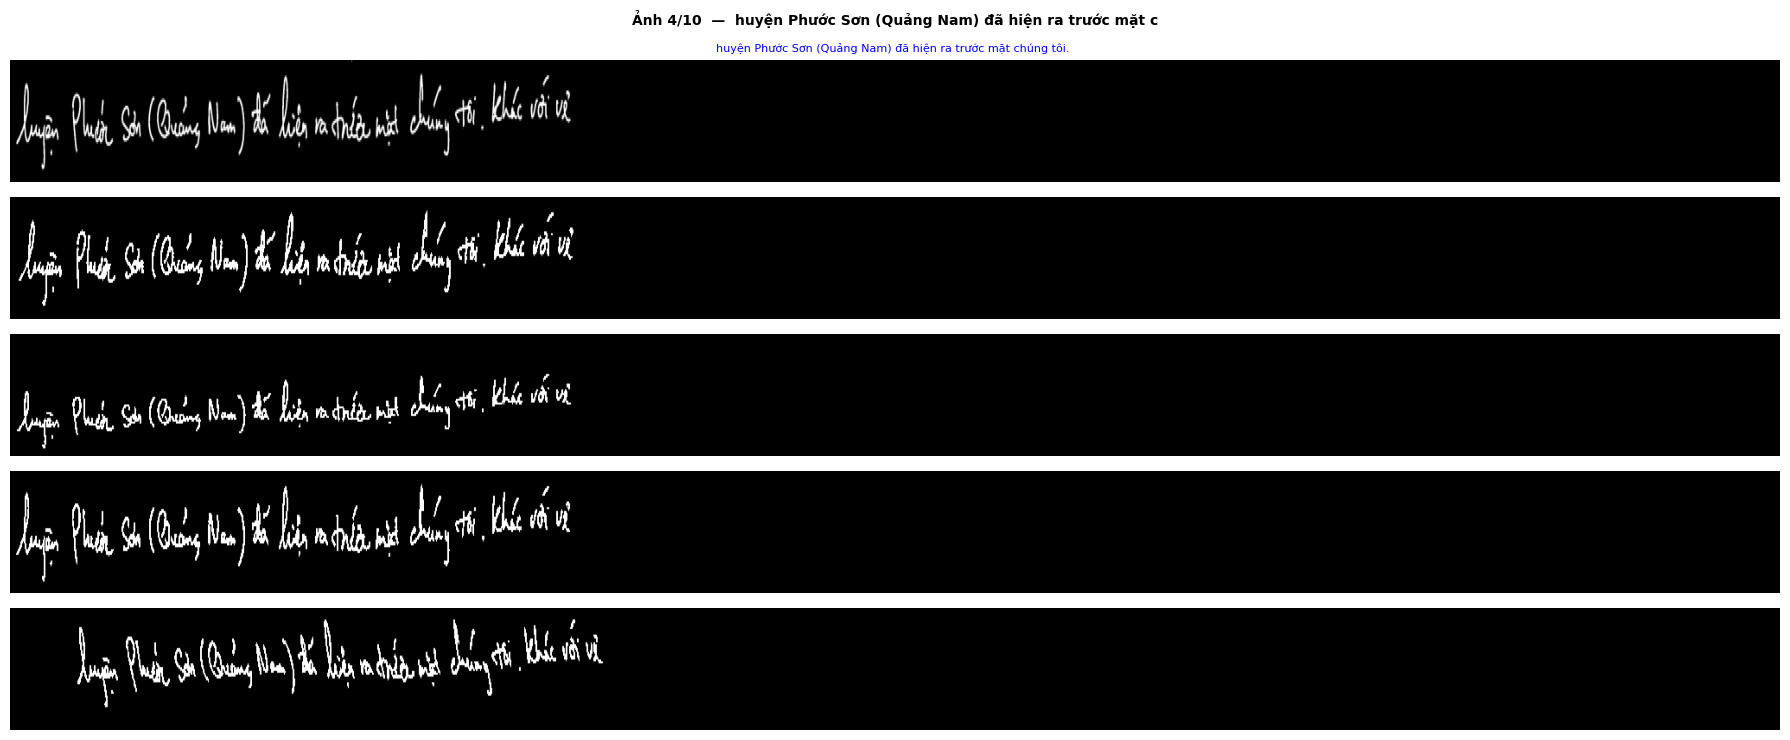

[4] huyện Phước Sơn (Quảng Nam) đã hiện ra trước mặt chúng tôi. Khác với vẻ


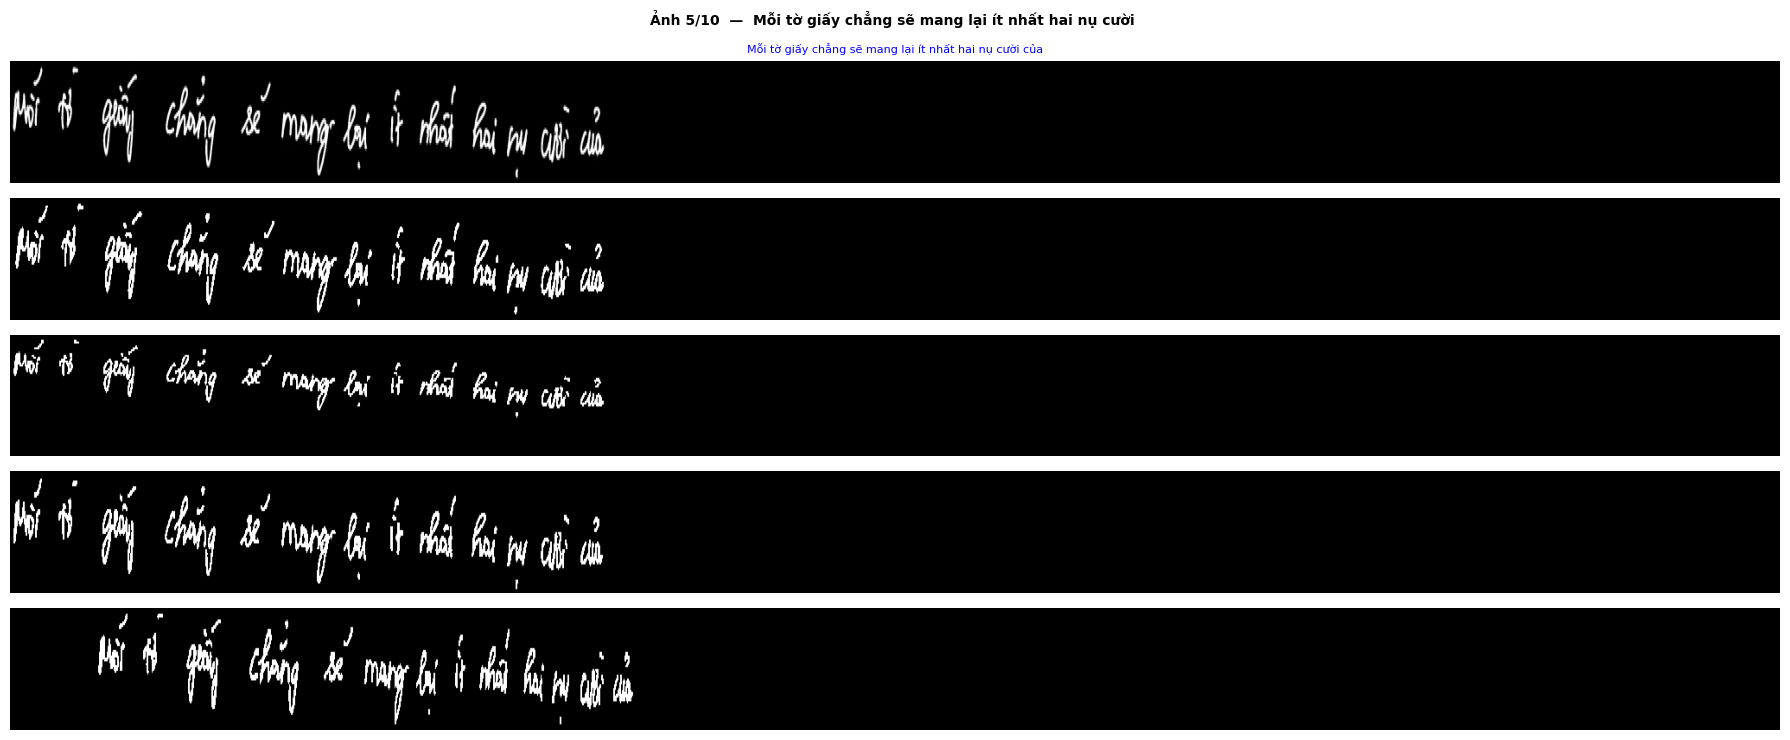

[5] Mỗi tờ giấy chẳng sẽ mang lại ít nhất hai nụ cười của


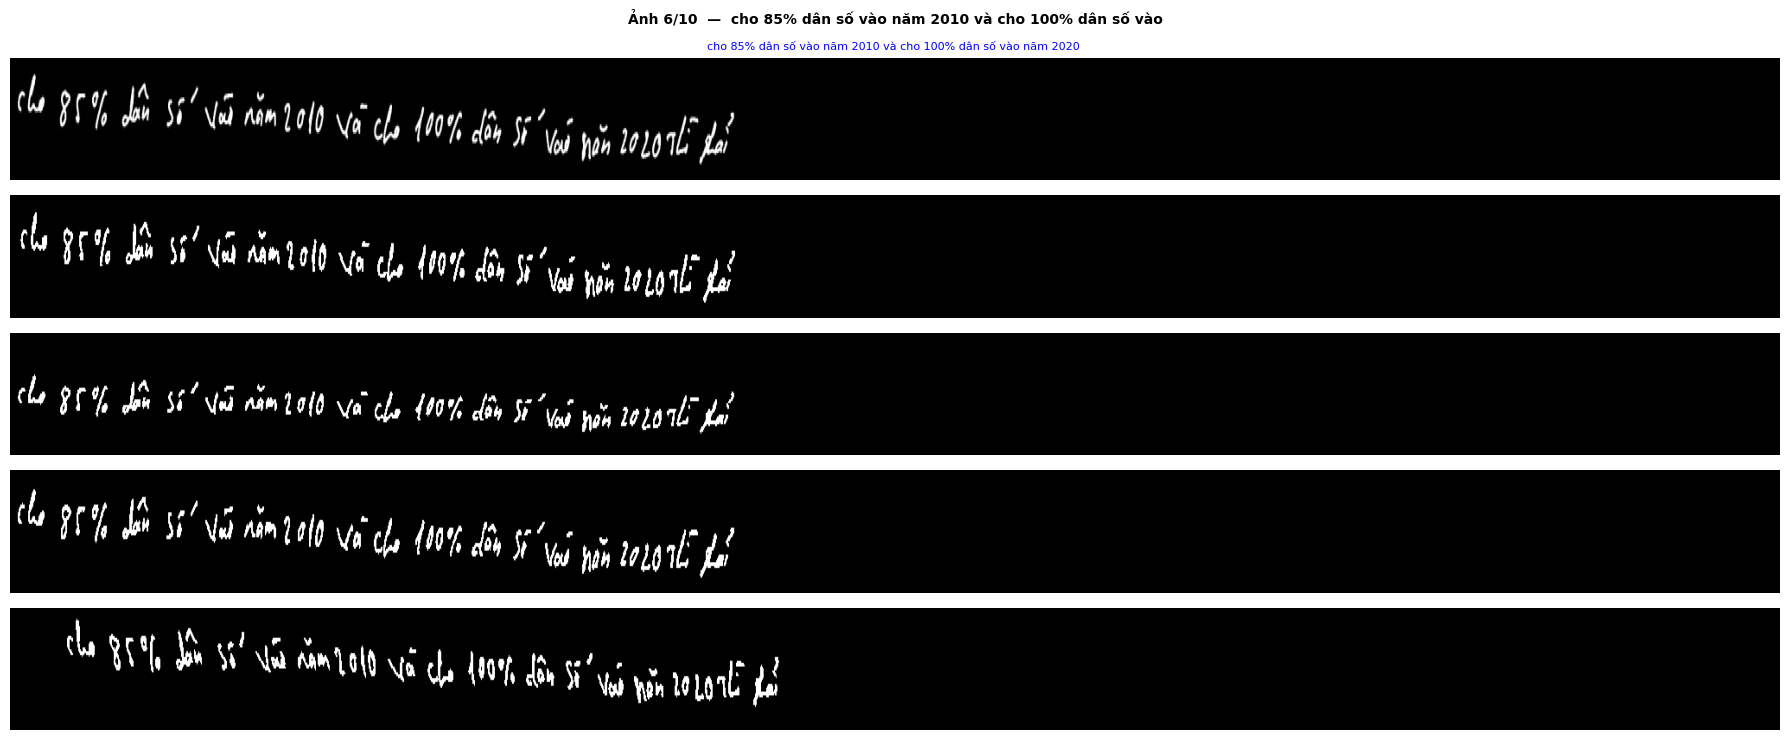

[6] cho 85% dân số vào năm 2010 và cho 100% dân số vào năm 2020 thì phải


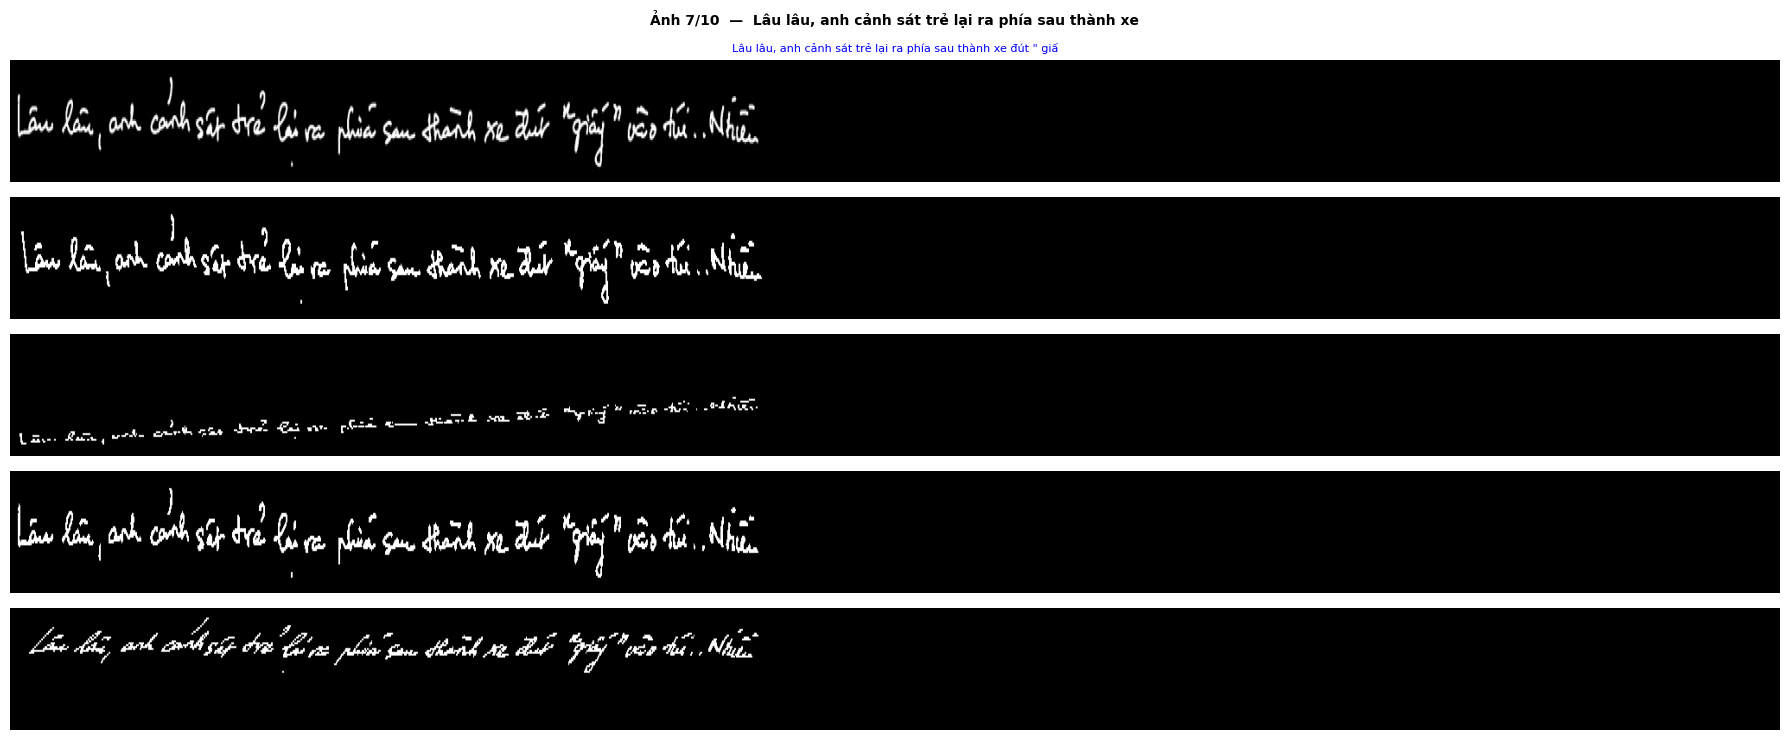

[7] Lâu lâu, anh cảnh sát trẻ lại ra phía sau thành xe đút " giấy " vào túi... Nhiều


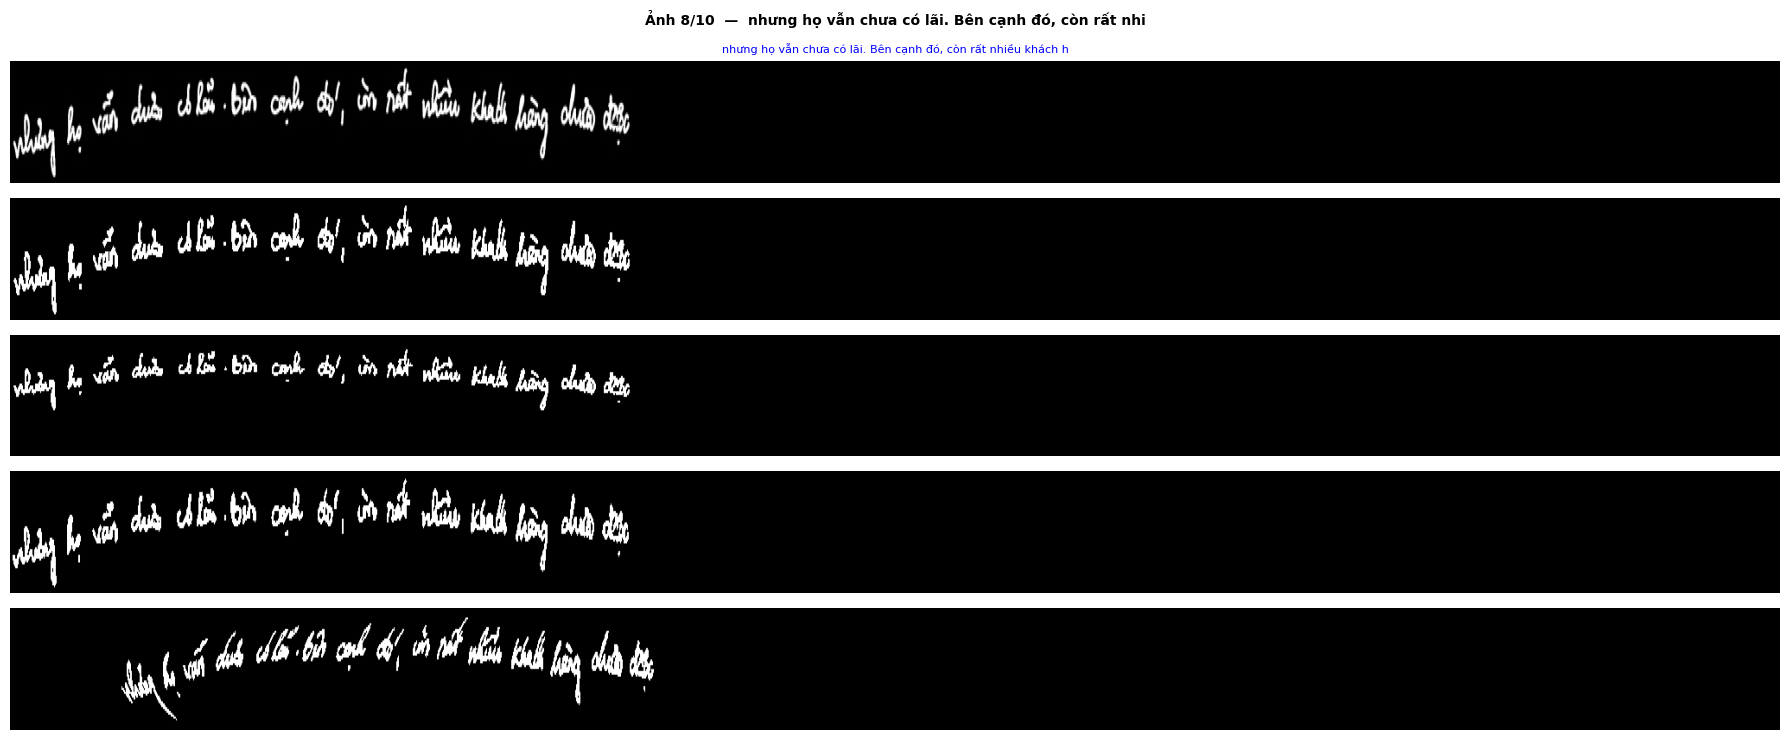

[8] nhưng họ vẫn chưa có lãi. Bên cạnh đó, còn rất nhiều khách hàng chưa được


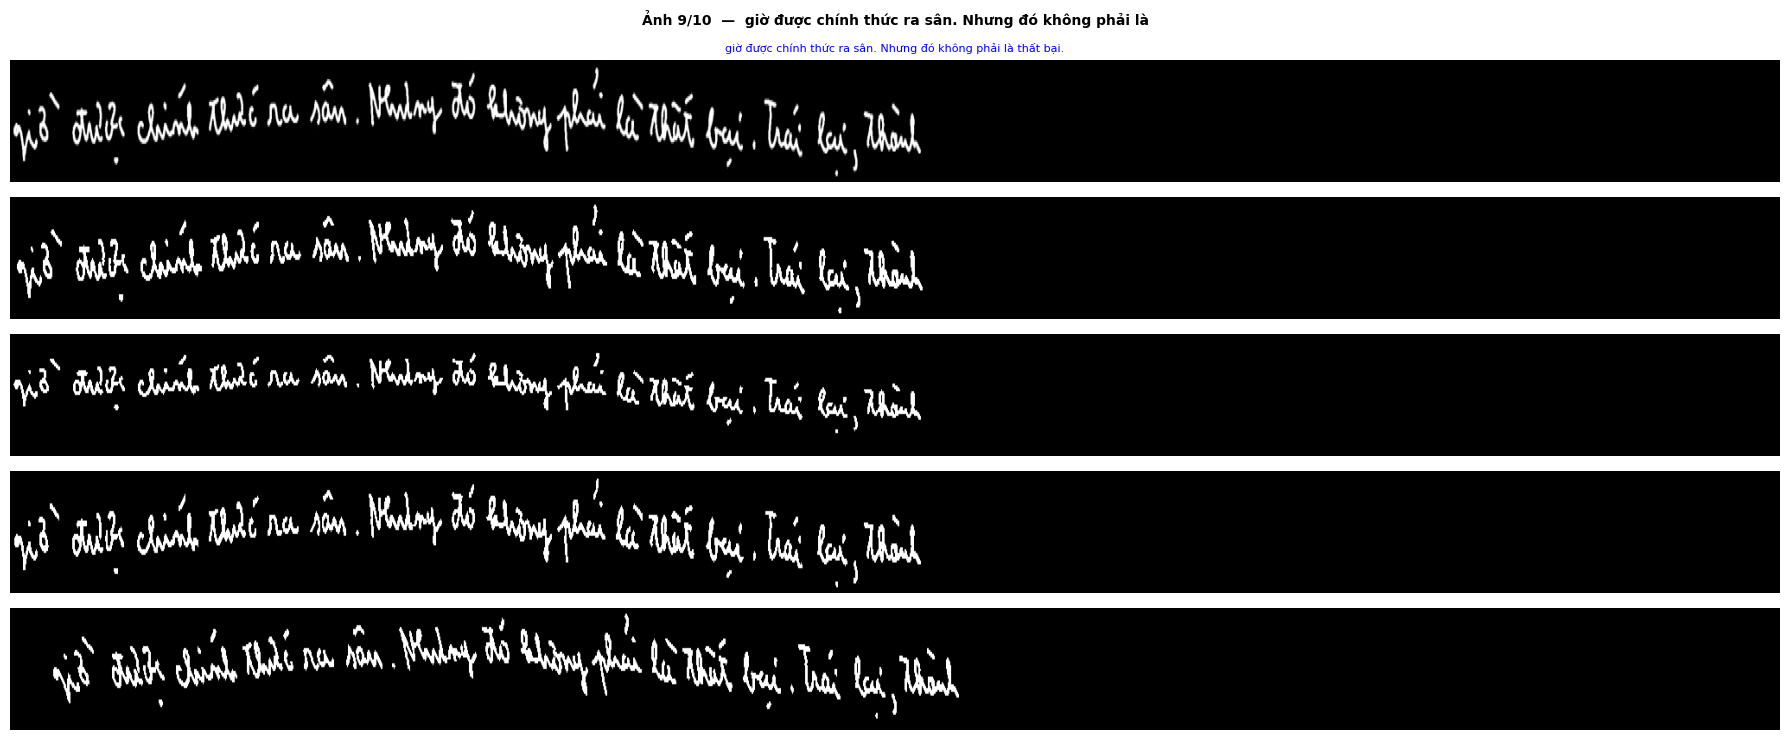

[9] giờ được chính thức ra sân. Nhưng đó không phải là thất bại. Trái lại, thành


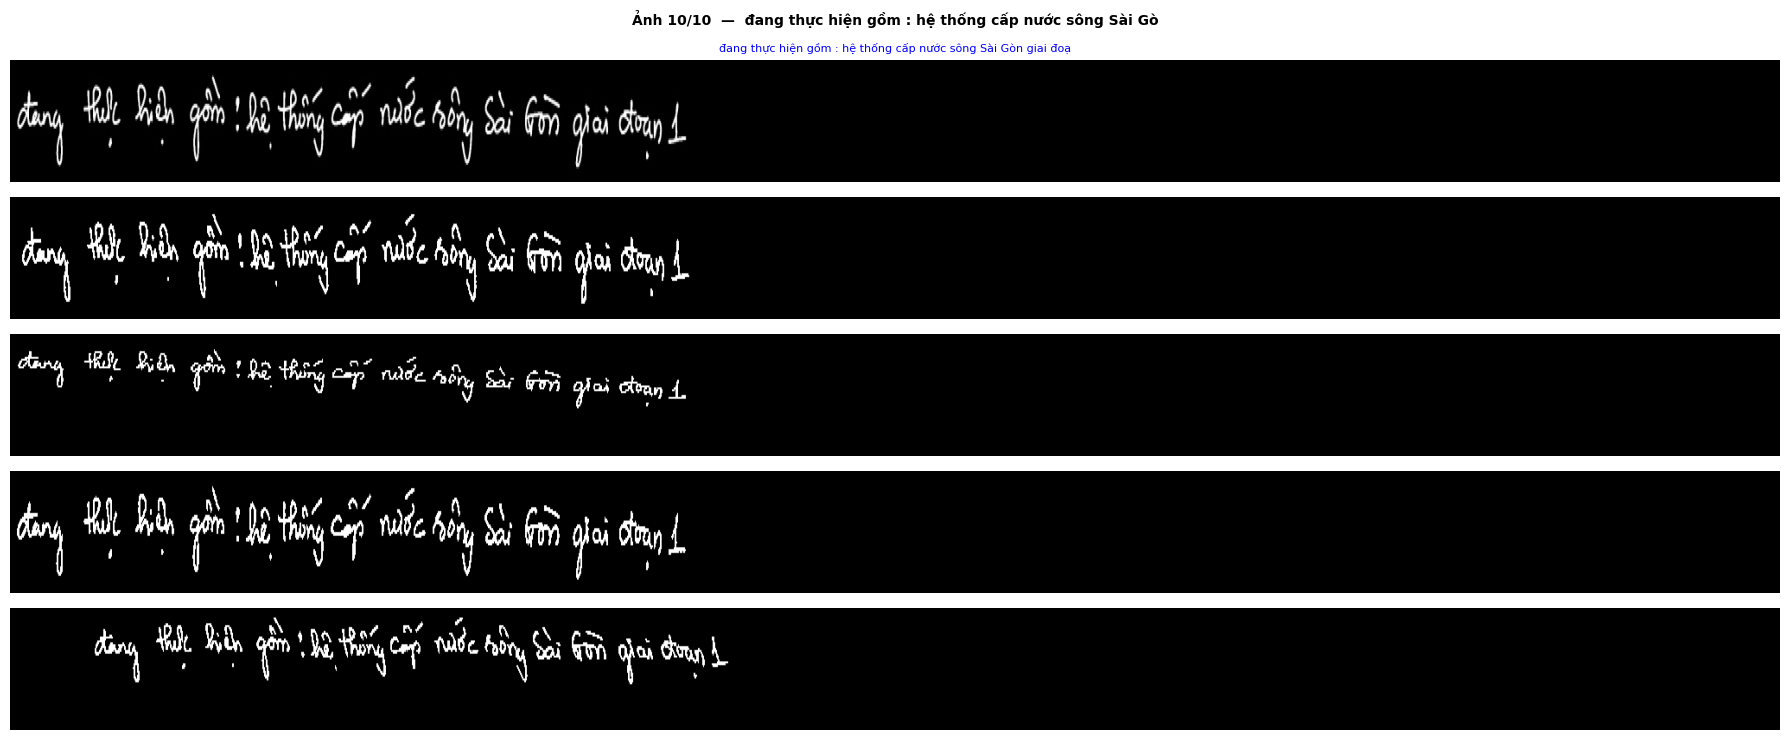

[10] đang thực hiện gồm : hệ thống cấp nước sông Sài Gòn giai đoạn 1


In [187]:
def visualize_augmentations_v4(entries, root_path, num_images=5):
    samples = random.sample(entries, min(num_images, len(entries)))
    aug_ops = ["shear", "rotation", "elastic", "geometric"]
    n_rows  = len(aug_ops) + 1  # 1 gốc + 4 aug

    for img_idx, item in enumerate(samples):
        img_path = root_path / item["image"]
        label    = item.get("text", "")

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Không đọc được: {img_path}")
            continue

        # n_rows hàng, mỗi hàng là 1 ảnh ngang 64×2048
        fig, axes = plt.subplots(
            n_rows, 1,
            figsize=(18, n_rows * 1.5)  # rộng cố định 18 inch, mỗi hàng cao 1.5 inch
        )

        # Hàng 0: ảnh gốc
        axes[0].imshow(img, cmap="gray", aspect="auto")
        axes[0].set_ylabel("Gốc", fontsize=9, color="blue", rotation=0,
                           labelpad=45, va="center")
        axes[0].set_title(label[:60], fontsize=8, color="blue")
        axes[0].axis("off")

        # Hàng 1-4: augmentation
        for row_idx, op in enumerate(aug_ops, start=1):
            if op == "shear":
                lo, hi  = VN_SAFE_CONFIG["aug"]["shear_range"]
                k       = random.uniform(lo, hi)
                aug_img = shear_image(img.copy(), k)
                ylabel  = f"Shear\nk={k:.2f}"

            elif op == "rotation":
                lo, hi  = VN_SAFE_CONFIG["aug"]["rotation_range"]
                theta   = random.uniform(lo, hi)
                aug_img = rotate_image(img.copy(), theta)
                ylabel  = f"Rotate\n{theta:.1f}°"

            elif op == "elastic":
                sigma   = random.choice(VN_SAFE_CONFIG["aug"]["elastic_sigma"])
                alpha   = random.choice(VN_SAFE_CONFIG["aug"]["elastic_alpha"])
                aug_img = elastic_image(img.copy(), sigma, alpha)
                ylabel  = f"Elastic\nσ={sigma} α={alpha}"

            else:
                aug_img = geometric_image(img.copy())
                ylabel  = "Geometric"

            axes[row_idx].imshow(aug_img, cmap="gray", aspect="auto")
            axes[row_idx].set_ylabel(ylabel, fontsize=8, color="green",
                                     rotation=0, labelpad=55, va="center")
            axes[row_idx].axis("off")

        plt.suptitle(f"Ảnh {img_idx+1}/{num_images}  —  {label[:50]}",
                     fontsize=10, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"aug_check_img{img_idx+1}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[{img_idx+1}] {label}")


visualize_augmentations_v4(train_entries, ROOT, num_images=10)


In [188]:
# ==================== MODEL DEFINITION ====================
class CNNBiLSTMCTC(nn.Module):
    def __init__(self, num_classes, input_height=100):
        super(CNNBiLSTMCTC, self).__init__()
        
        self.num_classes = num_classes
        
        # ==================== CNN BLOCK ====================
        # Block 1: 32 filters - học các cạnh
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/2
        self.dropout1 = nn.Dropout(0.2)
        
        # Block 2: 64 filters - học các cấu trúc phức tạp hơn như móc, góc
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        self.conv6 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(64)
        
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/4
        self.dropout2 = nn.Dropout(0.3)
        
        # Block 3: 128 filters
        self.conv7 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn7 = nn.BatchNorm2d(128)
        
        self.conv8 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn8 = nn.BatchNorm2d(128)
        
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn9 = nn.BatchNorm2d(128)
        
        self.conv10 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn10 = nn.BatchNorm2d(128)
        
        self.conv11 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn11 = nn.BatchNorm2d(128)
        
        self.conv12 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn12 = nn.BatchNorm2d(128)
        # self.dropout3 = nn.Dropout(0.4)

        # After column-wise pooling in forward(), each time-step has 128 features.
        self.rnn_input_size = 128
        
        
        # ==================== BiLSTM BLOCK ====================
        self.lstm1 = nn.LSTM(
            input_size=self.rnn_input_size,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=False
        )
        
        self.lstm2 = nn.LSTM(
            input_size=512,  # 256 * 2 (bidirectional)
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=False
        )
        
        # ==================== CTC OUTPUT ====================
        self.fc1 = nn.Linear(512, 512)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # CNN Forward
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = F.relu(self.bn9(self.conv9(x)))
        x = F.relu(self.bn10(self.conv10(x)))
        x = F.relu(self.bn11(self.conv11(x)))
        x = F.relu(self.bn12(self.conv12(x)))
        # x = self.dropout3(x)
        
        # Column-wise max pooling
        x = F.max_pool2d(x, kernel_size=(x.size(2), 1))
        
        # Reshape for RNN
        x = x.squeeze(2)  # (B, 128, W)
        x = x.permute(2, 0, 1)  # (W, B, 128)
        
        # BiLSTM
        x, _ = self.lstm1(x)
        # x = self.dropout_lstm(x)
        x, _ = self.lstm2(x)
        # x = self.dropout_lstm(x)
        
        # Output
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout_fc(x)
        x = self.fc2(x)
        
        # Log softmax for CTC
        # x = F.log_softmax(x, dim=2)
        
        return x

In [189]:
# ==================== DATASET CLASS ====================


class HandwritingDataset(Dataset):

    def __init__(self, image_paths, labels, char_to_idx, is_training=True):

        self.image_paths = image_paths
        self.labels = labels
        self.char_to_idx = char_to_idx
        self.is_training = is_training
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load and preprocess image
        img_path = self.image_paths[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(f"Cannot read image at index {idx}: {img_path}")
        
        if self.is_training:
            img, aug_name = apply_single_aug_paper(img, p_apply=0.5)
        
        # Resize to target size
        #img = cv2.resize(img, (self.input_width, self.input_height))
        
        # h, w = img.shape[:2]
        # new_h = self.input_height # Thường là 100
        # # Tính toán chiều rộng mới dựa trên chiều cao mục tiêu
        # new_w = int(w * (new_h / h))
        
        # # Giới hạn chiều rộng không vượt quá input_width (1280)
        # new_w = min(new_w, self.input_width)
        # img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        
        # # 3. Padding phần còn thiếu vào bên phải
        # # Tạo một khung ảnh trống (màu đen = 0) với kích thước mục tiêu
        # final_img = np.zeros((self.input_height, self.input_width), dtype=np.uint8)
        # # Chèn ảnh đã resize vào góc trên bên trái
        # final_img[:, :new_w] = img

        # 4. Normalize và định dạng Tensor
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0) # (1, H, W)

        # # Normalize to [0, 1]
        # img = img.astype(np.float32) / 255.0
        
        # # Add channel dimension: (H, W) -> (1, H, W)
        # img = np.expand_dims(img, axis=0)
        
        # Convert label to indices
        label = self.labels[idx]
        label_indices = [self.char_to_idx[c] for c in label if c in self.char_to_idx]
        
        return torch.FloatTensor(img), torch.LongTensor(label_indices)


def collate_fn(batch):
    images, labels = zip(*batch)
    images        = torch.stack(images, dim=0)  # (B, 1, 64, 2048)
    label_lengths = torch.LongTensor([len(lbl) for lbl in labels])
    labels_concat = torch.cat(labels)
    return images, labels_concat, label_lengths


def load_labels_csv(csv_path):
    image_paths = []
    labels = []

    # Use utf-8-sig so BOM-prefixed headers (\ufeffimage_path) are parsed correctly.
    with open(csv_path, mode='r', encoding='utf-8-sig', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            image_path = (row.get('image_path') or row.get('\ufeffimage_path') or '').strip()
            text = row.get('text') or row.get('label') or ''
            exists_val = (row.get('exists') or '').strip().lower()

            if not image_path:
                continue
            if exists_val and exists_val not in {'true', '1', 'yes'}:
                continue
            if not Path(image_path).exists():
                continue

            image_paths.append(image_path)
            labels.append(text)

    return image_paths, labels




In [190]:

import heapq
from collections import defaultdict

# ==================== TRAINING FUNCTION ====================
def train_epoch(model, dataloader, criterion, optimizer, device):
 
    model.train()
    total_loss = 0
    start_time = time.time()

    
    for i, (images, labels, label_lengths) in enumerate(tqdm(dataloader, desc="Training", mininterval=0.5, leave=False)):
        
        data_time = time.time() - start_time
        step_start = time.time()

        # Move to device
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Forward pass
        logits = model(images)  # (T, B, C)

        log_probs = F.log_softmax(logits, dim=2)
        
        # Get input lengths (all sequences have same length after CNN)
        input_lengths = torch.full(
            size=(images.size(0),), 
            fill_value=log_probs.size(0), 
            dtype=torch.long
        )
        
        # Compute CTC loss
        loss = criterion(
            log_probs=log_probs,
            targets=labels,
            input_lengths=input_lengths,
            target_lengths=label_lengths
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        step_time = time.time() - step_start
        if i % 50 == 0:
            logging.info(
                f"Batch {i} | Data: {data_time:.3f}s | Step: {step_time:.3f}s"
                f" | Loss: {loss.item():.4f}"
            )
 
        total_loss += loss.item()
        start_time  = time.time()
    
    return total_loss / len(dataloader)


# ==================== VALIDATION FUNCTION ====================
def validate(model, dataloader, criterion, device, idx_to_char):
    model.eval()
    total_loss = 0
    all_pred_texts = []
    all_target_texts = []
    
    with torch.no_grad():
        for images, labels, label_lengths in tqdm(
            dataloader, desc="Validation", mininterval=0.5, leave=False
        ):
            # Move to device
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass
            logits = model(images)
            log_probs = F.log_softmax(logits, dim=2)
            
            # Get input lengths
            input_lengths = torch.full(
                size=(images.size(0),), 
                fill_value=log_probs.size(0), 
                dtype=torch.long
            )
            
            # Compute loss
            loss = criterion(
                log_probs=log_probs,
                targets=labels,
                input_lengths=input_lengths,
                target_lengths=label_lengths
            )
            
            total_loss += loss.item()

            pred_texts = greedy_decode(log_probs.cpu(), idx_to_char)
            target_texts = targets_to_strings(labels, label_lengths, idx_to_char)
            all_pred_texts.extend(pred_texts)
            all_target_texts.extend(target_texts)
    
    avg_loss = total_loss / len(dataloader)
    metrics = compute_ocr_metrics(all_pred_texts, all_target_texts)
    return avg_loss, metrics


# ==================== DECODING FUNCTION ====================
def greedy_decode(log_probs, idx_to_char, blank_idx=0):

    # Get predictions: (T, B)
    predictions = torch.argmax(log_probs, dim=2)
    predictions = predictions.permute(1, 0)  # (B, T)
    
    decoded_strings = []
    
    for pred in predictions:
        # Remove blanks and consecutive duplicates
        chars = []
        prev_idx = None
        
        for idx in pred:
            idx = idx.item()
            
            # Skip blanks
            if idx == blank_idx:
                prev_idx = None
                continue
            
            # Skip consecutive duplicates
            if idx == prev_idx:
                continue
            
            # Add character
            if idx in idx_to_char:
                chars.append(idx_to_char[idx])
            
            prev_idx = idx
        
        decoded_strings.append(''.join(chars))
    
    return decoded_strings


def beam_search_decode(log_probs, idx_to_char, blank_idx=0, beam_width=10):
    T, B, C = log_probs.shape
    probs = log_probs.exp().cpu().numpy()  # (T, B, C)
    
    results = []
    for b in range(B):
        # Beam: list of (score, last_char_idx, decoded_chars_tuple)
        # score là log probability (âm), dùng min-heap → negate
        beams = [(0.0, blank_idx, ())]  # (neg_log_prob, last_idx, chars)
        
        for t in range(T):
            new_beams = defaultdict(lambda: float('-inf'))
            
            for neg_score, last_idx, chars in beams:
                for c in range(C):
                    p = probs[t, b, c]
                    if p < 1e-10:
                        continue
                    new_score = neg_score + np.log(p + 1e-10)
                    
                    if c == blank_idx:
                        # Blank: giữ nguyên sequence
                        key = (last_idx, chars)
                    elif c == last_idx:
                        # Duplicate: CTC collapse
                        key = (last_idx, chars)
                    else:
                        key = (c, chars + (c,))
                    
                    if new_score > new_beams[key]:
                        new_beams[key] = new_score
            
            # Giữ top beam_width
            beams = sorted(
                [(score, last_idx, chars) for (last_idx, chars), score in new_beams.items()],
                key=lambda x: -x[0]
            )[:beam_width]
        
        # Lấy beam tốt nhất
        best_chars = beams[0][2] if beams else ()
        text = ''.join(idx_to_char.get(c, '') for c in best_chars)
        results.append(text)
    
    return results


def targets_to_strings(labels_concat, label_lengths, idx_to_char):
    labels_list = labels_concat.detach().cpu().tolist()
    lengths_list = label_lengths.detach().cpu().tolist()

    decoded_strings = []
    start = 0
    for length in lengths_list:
        token_ids = labels_list[start:start + length]
        start += length
        chars = [idx_to_char.get(int(idx), '') for idx in token_ids if int(idx) != 0]
        decoded_strings.append(''.join(chars))

    return decoded_strings


def _levenshtein_distance(seq1, seq2):
    if len(seq1) < len(seq2):
        seq1, seq2 = seq2, seq1

    previous_row = list(range(len(seq2) + 1))
    for i, item1 in enumerate(seq1, start=1):
        current_row = [i]
        for j, item2 in enumerate(seq2, start=1):
            insertions = previous_row[j] + 1
            deletions = current_row[j - 1] + 1
            substitutions = previous_row[j - 1] + (item1 != item2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]


def compute_ocr_metrics(pred_texts, target_texts):
    total_samples = len(target_texts)
    if total_samples == 0:
        return {'seq_acc': 0.0, 'cer': 0.0, 'wer': 0.0, 'norm_edit_similarity': 0.0}

    exact_matches = 0
    total_char_dist = 0
    total_chars = 0
    total_word_dist = 0
    total_words = 0
    norm_edit_similarity_sum = 0.0

    for pred, target in zip(pred_texts, target_texts):
        if pred == target:
            exact_matches += 1

        char_dist = _levenshtein_distance(pred, target)
        total_char_dist += char_dist
        total_chars += max(len(target), 1)

        pred_words = pred.split()
        target_words = target.split()
        word_dist = _levenshtein_distance(pred_words, target_words)
        total_word_dist += word_dist
        total_words += max(len(target_words), 1)

        denom = max(len(pred), len(target), 1)
        norm_edit_similarity_sum += 1.0 - (char_dist / denom)

    metrics = {
        'seq_acc': exact_matches / total_samples,
        'cer': total_char_dist / total_chars,
        'wer': total_word_dist / total_words,
        'norm_edit_similarity': norm_edit_similarity_sum / total_samples,
    }

    return metrics




In [191]:
# ==================== MAIN TRAINING LOOP ====================
import logging
import time

# from marshmallow import missing

# Cấu hình logging
logging.basicConfig(
    filename='training_debug.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w'
)
logger = logging.getLogger(__name__)

def main():

    # Configuration
    BATCH_SIZE = 16
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 200
    # EARLY_STOPPING_PATIENCE = 10
    NUM_WORKERS = 4
    
    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    if device.type == 'cuda':
        torch.backends.cudnn.benchmark = True
    
    # Create character vocabulary
    # Example: Vietnamese alphabet + digits + punctuation
    vietnamese_chars = (
        "aàáảãạăằắẳẵặâầấẩẫậ"
        "eèéẻẽẹêềếểễệ"
        "iìíỉĩị"
        "oòóỏõọôồốổỗộơờớởỡợ"
        "uùúủũụưừứửữự"
        "yỳýỷỹỵ"

        "AÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬ"
        "EÈÉẺẼẸÊỀẾỂỄỆ"
        "IÌÍỈĨỊ"
        "OÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢ"
        "UÙÚỦŨỤƯỪỨỬỮỰ"
        "YỲÝỶỸỴ"
        "bcdđfghjklmnpqrstvwxz"
        "BCDĐFGHJKLMNPQRSTVWXZ"
        "0123456789"
        " .,:;!?-"
        "()/&*%\""
    )


    
    # Create mapping
    char_to_idx = {char: idx + 1 for idx, char in enumerate(vietnamese_chars)}  # +1 for blank
    char_to_idx['<blank>'] = 0  # Blank token at index 0
    idx_to_char = {idx: char for char, idx in char_to_idx.items()}
    
    num_classes = len(char_to_idx)
    print(f"Number of classes: {num_classes}")
    
    # Load train/validation data from prepared CSV files.
    # In notebooks, __file__ is not defined, so fall back to current working directory.
    base_dir = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
    data_root = base_dir / 'data_daxuli'

    if not data_root.exists() and (Path.cwd() / 'data_daxuli').exists():
        data_root = Path.cwd() / 'data_daxuli'

    train_csv = data_root / 'train_labels.csv'
    val_csv = data_root / 'validation_labels.csv'

    if not train_csv.exists() or not val_csv.exists():
        raise FileNotFoundError(
            f"Missing label CSV files. Expected: {train_csv} and {val_csv}"
        )

    train_image_paths, train_labels = load_labels_csv(train_csv)
    val_image_paths, val_labels = load_labels_csv(val_csv)

    all_chars = set(''.join(train_labels + val_labels))
    missing   = all_chars - set(vietnamese_chars)
    print("Ký tự thiếu trong vocab:", missing)

    if not train_image_paths or not val_image_paths:
        raise RuntimeError(
            "No valid samples loaded from CSV. Check image_path/exists columns and file paths."
        )

    print(f"\nLoaded train samples: {len(train_image_paths):,}")
    print(f"Loaded validation samples: {len(val_image_paths):,}")
    
    # Create datasets
    train_dataset = HandwritingDataset(
        train_image_paths, 
        train_labels, 
        char_to_idx
    )
    
    val_dataset = HandwritingDataset(
        val_image_paths, 
        val_labels, 
        char_to_idx
    )
    
    # DataLoader options for better notebook throughput on Windows
    pin_memory = device.type == 'cuda'
    persistent_workers = NUM_WORKERS > 0

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        collate_fn=collate_fn
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        collate_fn=collate_fn
    )
    
    # Create model
    model = CNNBiLSTMCTC(num_classes=num_classes)
    model = model.to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nTotal parameters: {total_params:,}")
    
    # Loss function
    criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
    
    # Optimizer
    optimizer = torch.optim.RMSprop(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-5
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )
    
    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0
    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'lr': [],
        'val_seq_acc': [],
        'val_cer': [],
        'val_wer': [],
        'val_norm_edit_similarity': [],
    }
    checkpoint_dir = base_dir / 'checkpoints'
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = checkpoint_dir / 'best_model.pth'
    last_model_path = checkpoint_dir / 'last_model.pth'
    print(f"Checkpoint directory: {checkpoint_dir}")
    
    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70)
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 70)
        
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")
        
        # Validate
        val_loss, val_metrics = validate(model, val_loader, criterion, device, idx_to_char)
        print(f"Val Loss: {val_loss:.4f}")
        print(
            f"Val SeqAcc: {val_metrics['seq_acc']:.4f} | "
            f"CER: {val_metrics['cer']:.4f} | "
            f"WER: {val_metrics['wer']:.4f} | "
            f"NormEditSim: {val_metrics['norm_edit_similarity']:.4f}"
        )
        
        # Learning rate scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['lr'].append(float(current_lr))
        history['val_seq_acc'].append(float(val_metrics['seq_acc']))
        history['val_cer'].append(float(val_metrics['cer']))
        history['val_wer'].append(float(val_metrics['wer']))
        history['val_norm_edit_similarity'].append(float(val_metrics['norm_edit_similarity']))
        
        # Always save latest checkpoint so a model file exists after training.
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_metrics': val_metrics,
            'char_to_idx': char_to_idx,
            'history': history,
        }, str(last_model_path))
        
        # Save best model
        if np.isfinite(val_loss) and val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_metrics': val_metrics,
                'char_to_idx': char_to_idx,
                'best_val_loss': best_val_loss,
                'history': history,
            }, str(best_model_path))
            print(f"Saved best model (val_loss: {val_loss:.4f}) -> {best_model_path}")
        else:
            patience_counter += 1
        
        # # Early stopping
        # if patience_counter >= EARLY_STOPPING_PATIENCE:
        #     print(f"\nEarly stopping triggered after {epoch+1} epochs")
        #     break
    
    print("\n" + "="*70)
    print("TRAINING COMPLETED!")
    print("="*70)
    print(f"Last checkpoint: {last_model_path}")
    if best_model_path.exists():
        print(f"Best checkpoint: {best_model_path}")




In [192]:
if __name__ == "__main__":
    main()

Using device: cuda
Number of classes: 212
Ký tự thiếu trong vocab: set()

Loaded train samples: 4,993
Loaded validation samples: 1,181

Total parameters: 3,691,700
Checkpoint directory: /home/captain-cccp/Documents/NGA/ocr_tieng_viet/checkpoints

STARTING TRAINING

Epoch 1/200
----------------------------------------------------------------------


Training:  42%|████▏     | 130/313 [00:34<00:47,  3.82it/s]

Train Loss: 9.1119


Val Loss: 6.2929
Val SeqAcc: 0.0000 | CER: 0.7077 | WER: 1.0097 | NormEditSim: 0.2892
Saved best model (val_loss: 6.2929) -> /home/captain-cccp/Documents/NGA/ocr_tieng_viet/checkpoints/best_model.pth

Epoch 2/200
----------------------------------------------------------------------


Train Loss: 3.3141


...

Val Loss: 0.5138
Val SeqAcc: 0.0762 | CER: 0.1009 | WER: 0.2807 | NormEditSim: 0.8918

Epoch 199/200
----------------------------------------------------------------------


Train Loss: 0.1724


Val Loss: 0.5175
Val SeqAcc: 0.0796 | CER: 0.0986 | WER: 0.2750 | NormEditSim: 0.8942

Epoch 200/200
----------------------------------------------------------------------


Train Loss: 0.1674


Val Loss: 0.5004
Val SeqAcc: 0.0821 | CER: 0.0973 | WER: 0.2756 | NormEditSim: 0.8957

TRAINING COMPLETED!
Last checkpoint: /home/captain-cccp/Documents/NGA/ocr_tieng_viet/checkpoints/last_model.pth
Best checkpoint: /home/captain-cccp/Documents/NGA/ocr_tieng_viet/checkpoints/best_model.pth


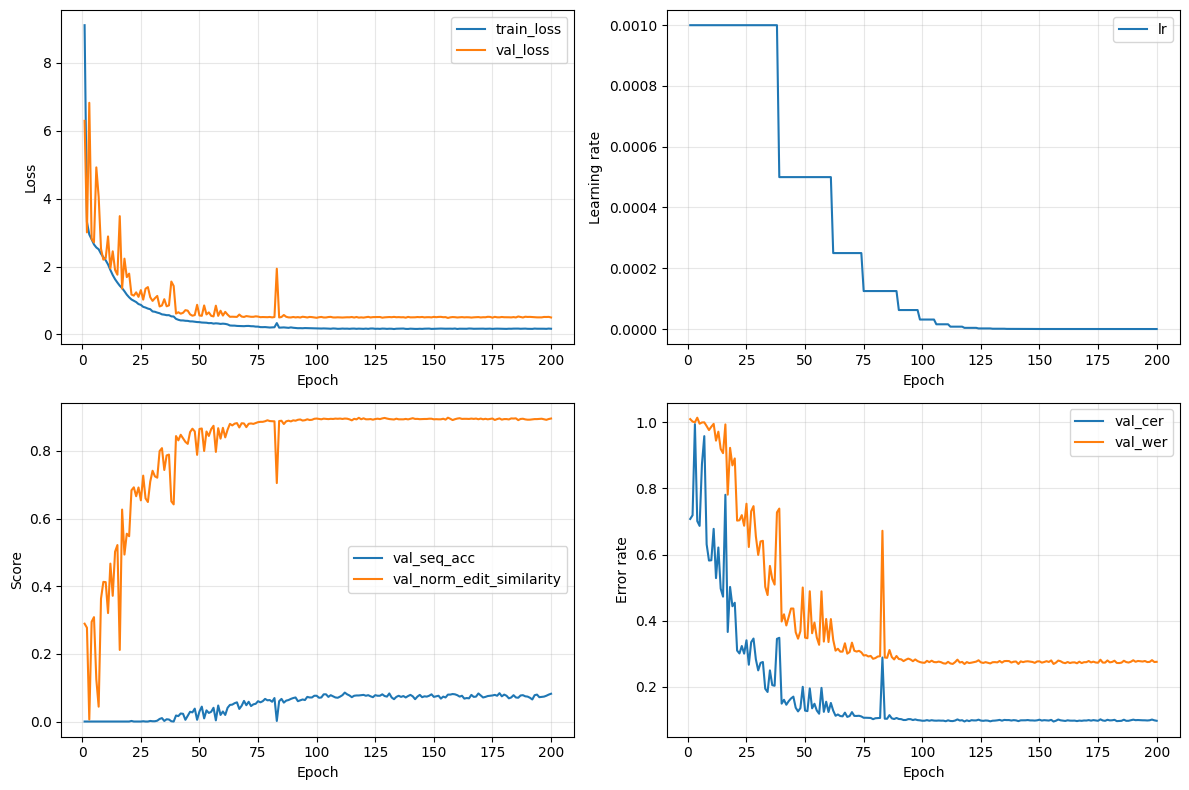

In [197]:
import torch
import matplotlib.pyplot as plt

ckpt = torch.load("checkpoints/last_model.pth", map_location="cpu")
history = ckpt["history"]

epochs = history["epoch"]
train_loss = history["train_loss"]
val_loss = history["val_loss"]
lr = history["lr"]
val_seq_acc = history.get("val_seq_acc", [])
val_cer = history.get("val_cer", [])
val_wer = history.get("val_wer", [])
val_norm_edit_similarity = history.get("val_norm_edit_similarity", [])

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(epochs, train_loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2,2,2)
plt.plot(epochs, lr, label="lr")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.legend()
plt.grid(True, alpha=0.3)

if val_seq_acc:
    plt.subplot(2,2,3)
    plt.plot(epochs, val_seq_acc, label="val_seq_acc")
    plt.plot(epochs, val_norm_edit_similarity, label="val_norm_edit_similarity")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2,2,4)
    plt.plot(epochs, val_cer, label="val_cer")
    plt.plot(epochs, val_wer, label="val_wer")
    plt.xlabel("Epoch")
    plt.ylabel("Error rate")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [194]:
# import torch

# # 1. Load file checkpoint của bạn
# checkpoint_path = r"F:\OneDrive\TAI_LIEU_HK8\XLA\ocr_tieng_viet\checkpoints1\best_model.pth" # Thay bằng đường dẫn thật
# ckpt = torch.load(checkpoint_path, map_location='cpu')

# # Lấy state_dict (tùy vào cách bạn lưu, có thể là ckpt trực tiếp hoặc ckpt['model_state_dict'])
# state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt

# print(f"{'Tên lớp (Layer Name)':<30} | {'Kích thước (Shape)':<20}")
# print("-" * 60)

# # 2. In ra kích thước của các lớp quan trọng để tìm thông số
# for key, value in state_dict.items():
#     # Chỉ in một số lớp đại diện để không bị quá dài
#     if any(x in key for x in ['conv1.weight', 'lstm1.weight_ih_l0', 'fc.weight', 'fc2.weight']):
#         print(f"{key:<30} | {str(list(value.shape)):<20}")

# print("-" * 60)

In [198]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader

# ==================== TEST / INFERENCE ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = Path.cwd()
checkpoint_dir = base_dir / "checkpoints"

best_model_path = checkpoint_dir / "best_model.pth"
last_model_path = checkpoint_dir / "last_model.pth"

if best_model_path.exists():
    checkpoint_path = best_model_path
elif last_model_path.exists():
    checkpoint_path = last_model_path
else:
    raise FileNotFoundError(
        f"No checkpoint found. Expected one of: {best_model_path} or {last_model_path}"
    )

ckpt = torch.load(str(checkpoint_path), map_location=device)

if isinstance(ckpt, dict) and "char_to_idx" in ckpt:
    char_to_idx = ckpt["char_to_idx"]
else:
    raise KeyError(
        "Checkpoint does not contain 'char_to_idx'. Re-train or save vocabulary in checkpoint."
    )

idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

model = CNNBiLSTMCTC(num_classes=num_classes).to(device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"], strict=False)
else:
    # Backward compatibility: checkpoint might be a raw state_dict
    model.load_state_dict(ckpt)

model.eval()
print(f"Loaded checkpoint: {checkpoint_path}")

data_root = base_dir / "data_daxuli"
test_csv = data_root / "test_labels.csv"

if not test_csv.exists():
    raise FileNotFoundError(f"Missing test CSV: {test_csv}")

test_image_paths, test_labels = load_labels_csv(test_csv)
if not test_image_paths:
    raise RuntimeError("No valid test samples loaded from CSV.")

test_dataset = HandwritingDataset(
    image_paths=test_image_paths,
    labels=test_labels,
    char_to_idx=char_to_idx,
    is_training=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=collate_fn
)

all_pred_texts = []
all_target_texts = []

with torch.no_grad():
    for images, labels, label_lengths in test_loader:
        images = images.to(device, non_blocking=True)
        logits    = model(images)
        log_probs = F.log_softmax(logits, dim=2)
        pred_texts = beam_search_decode(log_probs, idx_to_char, blank_idx=0, beam_width=10)
        target_texts = targets_to_strings(labels, label_lengths, idx_to_char)

        all_pred_texts.extend(pred_texts)
        all_target_texts.extend(target_texts)

metrics = compute_ocr_metrics(all_pred_texts, all_target_texts)
print(f"Test samples: {len(all_target_texts):,}")
print(f"Sequence Accuracy: {metrics['seq_acc']:.2%}")
print(f"CER: {metrics['cer']:.2%}")
print(f"WER: {metrics['wer']:.2%}")
print(f"Normalized Edit Similarity: {metrics['norm_edit_similarity']:.2%}")

print("\nSample predictions:")
for i, (pred, target) in enumerate(zip(all_pred_texts[:10], all_target_texts[:15]), start=1):
    print(f"{i:02d}. PRED: {pred}")
    print(f"    GT  : {target}")

Loaded checkpoint: /home/captain-cccp/Documents/NGA/ocr_tieng_viet/checkpoints/best_model.pth
Test samples: 1,055
Sequence Accuracy: 7.87%
CER: 11.03%
WER: 29.65%
Normalized Edit Similarity: 88.29%

Sample predictions:
01. PRED: Pả sới gà náo động. Lượng tên " cấp tăng chóng mặt, tỉ lộ cá cược thay đỏi liên tục. Chỉ
    GT  : Cả sới gà náo động. Lượng tiền " cốp " tăng chóng mặt, tỉ lệ cá cược thay đổi liên tục. Chỉ
02. PRED: tong ti phút, lượng tiều cộc trên sùn đã lên tới vài chục triệu đừng. Đã hết hồ thủ tn
    GT  : trong ít phút, lượng tiền cược trên sàn đã lên tới vài chục triệu đồng. Đã hết hồ thứ sáu
03. PRED: ( mỗi trệm được tích làm kh0hồ - hiệp đấu, môi lô 15 phút), cập gì văn chưa phân thắng
    GT  : (mỗi trận được tính làm 10 hồ - hiệp đấu, mỗi hồ 15 phút), cặp gà vẫn chưa phân thắng
04. PRED: bại. Sới tạm nghi cho lại đấu thủ hôi sức, dân đá gà tản ra ngời sống nức. Triấn
    GT  : bại. Sới tạm nghỉ cho hai đấu thủ hồi sức, dân đá gà tản ra ngồi uống nước. Tuấn
05. PRED

In [199]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader

# ==================== TEST / INFERENCE ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = Path.cwd()
checkpoint_dir = base_dir / "checkpoints"

best_model_path = checkpoint_dir / "best_model.pth"
last_model_path = checkpoint_dir / "last_model.pth"

if best_model_path.exists():
    checkpoint_path = best_model_path
elif last_model_path.exists():
    checkpoint_path = last_model_path
else:
    raise FileNotFoundError(
        f"No checkpoint found. Expected one of: {best_model_path} or {last_model_path}"
    )

ckpt = torch.load(str(checkpoint_path), map_location=device)

if isinstance(ckpt, dict) and "char_to_idx" in ckpt:
    char_to_idx = ckpt["char_to_idx"]
else:
    raise KeyError(
        "Checkpoint does not contain 'char_to_idx'. Re-train or save vocabulary in checkpoint."
    )

idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

model = CNNBiLSTMCTC(num_classes=num_classes).to(device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"], strict=False)
else:
    # Backward compatibility: checkpoint might be a raw state_dict
    model.load_state_dict(ckpt)

model.eval()
print(f"Loaded checkpoint: {checkpoint_path}")

data_root = base_dir / "data_daxuli"
test_csv = data_root / "test_new_labels.csv"

if not test_csv.exists():
    raise FileNotFoundError(f"Missing test CSV: {test_csv}")

test_image_paths, test_labels = load_labels_csv(test_csv)
if not test_image_paths:
    raise RuntimeError("No valid test samples loaded from CSV.")

test_dataset = HandwritingDataset(
    image_paths=test_image_paths,
    labels=test_labels,
    char_to_idx=char_to_idx,
    is_training=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=collate_fn
)

all_pred_texts = []
all_target_texts = []

with torch.no_grad():
    for images, labels, label_lengths in test_loader:
        images = images.to(device, non_blocking=True)
        logits    = model(images)
        log_probs = F.log_softmax(logits, dim=2)
        # pred_texts = greedy_decode(log_probs, idx_to_char)
        pred_texts = beam_search_decode(log_probs, idx_to_char, beam_width=10)
        target_texts = targets_to_strings(labels, label_lengths, idx_to_char)

        all_pred_texts.extend(pred_texts)
        all_target_texts.extend(target_texts)

metrics = compute_ocr_metrics(all_pred_texts, all_target_texts)
print(f"Test samples: {len(all_target_texts):,}")
print(f"Sequence Accuracy: {metrics['seq_acc']:.2%}")
print(f"CER: {metrics['cer']:.2%}")
print(f"WER: {metrics['wer']:.2%}")
print(f"Normalized Edit Similarity: {metrics['norm_edit_similarity']:.2%}")

print("\nSample predictions:")
for i, (pred, target) in enumerate(zip(all_pred_texts[:5], all_target_texts[:5]), start=1):
    print(f"{i:02d}. PRED: {pred}")
    print(f"    GT  : {target}")

Loaded checkpoint: /home/captain-cccp/Documents/NGA/ocr_tieng_viet/checkpoints/best_model.pth
Test samples: 1,838
Sequence Accuracy: 0.05%
CER: 21.92%
WER: 61.55%
Normalized Edit Similarity: 78.10%

Sample predictions:
01. PRED: Số3 Nguyễn Ngọc lú, Hà Nội.
    GT  : Số 3 Nguyễn Ngọc Vũ, Hà Nội
02. PRED: Số 30 Nguyễn Hông, lảng Họa Đông Ba, Hà Nội
    GT  : Số 30 Nguyên Hồng, Láng Hạ, Đống Đa, Hà Nội
03. PRED: Sẽ thái thình Đừng Sa, tà lợc.
    GT  : 58 Thái Thịnh, Đống Đa, Hà Nội
04. PRED: Số 3N khu phố 5 phương Tân biên, Biên Hòa, Đồng Nai
    GT  : Số 370/8 khu phố 5B, phường Tân Biên, Biên Hòa, Đồng Nai
05. PRED: Binh Trung Qua 6,25 20 đường Thùng Dương Phường lình Trang
    GT  : Vĩnh Trung Plaza, B, 255-257 đường Hùng Vương, phường Vĩnh Trung
